# Data Exploration - Reanalsysis (ERA5 and MERRA2)

In [16]:
import pathlib
import datetime

In [2]:
import xarray

In [58]:
import matplotlib
import cartopy

### ERA5 datasdet info

### MERRA2 dataset info
Reanalysis dataset used for aerosols
* dir location `/gws/nopw/j04/ew4energy/West_Africa_Merra-2pwd`
* file template `M2T1NXAER.5.12.4%3AMERRA2_401.tavg1_2d_aer_Nx.20200930.nc4.dap.nc4` 
* data time span 2015-2020
* data temporal resolution: 1 day per file


In [35]:
ew4_dir = pathlib.Path('/gws/nopw/j04/ew4energy/')

In [38]:
meteo_fname_template = 'MERRA2_400.tavg1_2d_slv_Nx.{dt.year:04d}{dt.month:02d}{dt.day:02d}.SUB.nc'
aero_fname_template = 'MERRA2_400.inst3_3d_aer_Nv.{dt.year:04d}{dt.month:02d}{dt.day:02d}.SUB.nc'

In [47]:
merra2_meteo_dir = ew4_dir / 'West_Africa_Merra-2_2015-2025_meteo' 
merra2_aero_dir = ew4_dir / 'West_Africa_Merra-2_2015-2025_aerosols' / '3d'

In [48]:
select_dt = datetime.datetime(2025,5,11,0,0)

In [49]:
merra2_meteo_sample = xarray.open_dataset(merra2_meteo_dir / f'{select_dt.year:04d}' / meteo_fname_template.format(dt=select_dt))

In [54]:
float(merra2_meteo_sample['lat'].min()), float(merra2_meteo_sample['lat'].max()), float(merra2_meteo_sample['lon'].min()), float(merra2_meteo_sample['lon'].max())

(0.5, 20.0, -20.0, 10.0)

In [50]:
merra2_meteo_sample

<xarray.Dataset> Size: 942kB
Dimensions:  (time: 24, lat: 40, lon: 49)
Coordinates:
  * time     (time) datetime64[ns] 192B 2025-05-11T00:30:00 ... 2025-05-11T23...
  * lat      (lat) float64 320B 0.5 1.0 1.5 2.0 2.5 ... 18.0 18.5 19.0 19.5 20.0
  * lon      (lon) float64 392B -20.0 -19.38 -18.75 -18.12 ... 8.75 9.375 10.0
Data variables:
    T2M      (time, lat, lon) float32 188kB ...
    U10M     (time, lat, lon) float32 188kB ...
    U2M      (time, lat, lon) float32 188kB ...
    V10M     (time, lat, lon) float32 188kB ...
    V2M      (time, lat, lon) float32 188kB ...
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg1_2d...
    Filename:                          MERRA2_400.tavg1_2d_slv_Nx.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   23:59:59.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

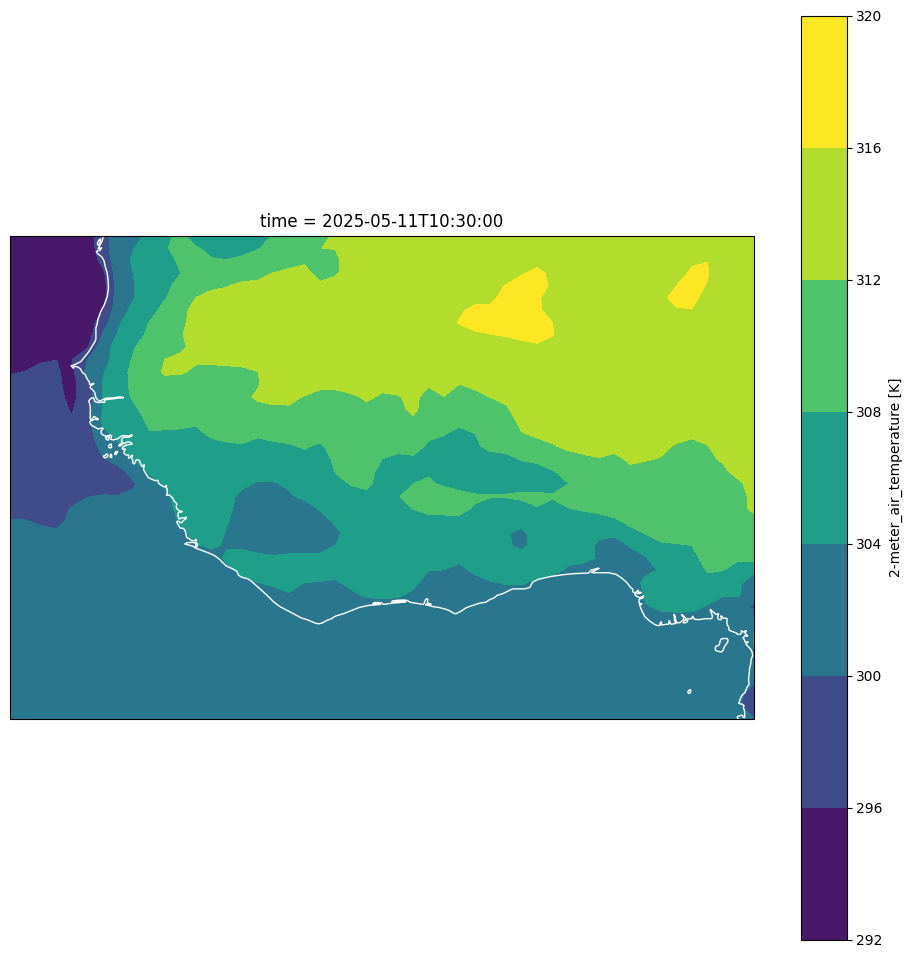

In [59]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
merra2_meteo_sample['T2M'][10].plot.contourf(ax=ax1)
ax1.coastlines(color='w')
merra2_meteo_sample['T2M']

In [51]:
merra2_aero_sample = xarray.open_dataset(merra2_aero_dir / f'{select_dt.year:04d}' / aero_fname_template.format(dt=select_dt))

In [52]:
merra2_aero_sample

<xarray.Dataset> Size: 95MB
Dimensions:   (time: 8, lev: 72, lat: 40, lon: 49)
Coordinates:
  * time      (time) datetime64[ns] 64B 2025-05-11 ... 2025-05-11T21:00:00
  * lev       (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
  * lat       (lat) float64 320B 0.5 1.0 1.5 2.0 2.5 ... 18.5 19.0 19.5 20.0
  * lon       (lon) float64 392B -20.0 -19.38 -18.75 -18.12 ... 8.75 9.375 10.0
Data variables: (12/23)
    AIRDENS   (time, lev, lat, lon) float32 5MB ...
    BCPHILIC  (time, lev, lat, lon) float32 5MB ...
    BCPHOBIC  (time, lev, lat, lon) float32 5MB ...
    DELP      (time, lev, lat, lon) float32 5MB ...
    DMS       (time, lev, lat, lon) float32 5MB ...
    DU001     (time, lev, lat, lon) float32 5MB ...
    ...        ...
    SO4       (time, lev, lat, lon) float32 5MB ...
    SS001     (time, lev, lat, lon) float32 5MB ...
    SS002     (time, lev, lat, lon) float32 5MB ...
    SS003     (time, lev, lat, lon) float32 5MB ...
    SS004     (time, lev, lat, lon) float32 5MB ...
    SS005     (time, lev, lat, lon) float32 5MB ...
Attributes: (12/32)
    CDI:                               Climate Data Interface version 1.9.8 (...
    Conventions:                       CF-1
    History:                           Original file generated: Wed May 21 20...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    Filename:                          MERRA2_400.inst3_3d_aer_Nv.20250511.nc4
    Institution:                       NASA Global Modeling and Assimilation ...
    ...                                ...
    RangeBeginningDate:                2025-05-11
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-05-11
    RangeEndingTime:                   21:00:00.000000
    history_L34RS:                     'Created by L34RS v1.4.4 @ NASA GES DI...
    CDO:                               Climate Data Operators version 1.9.8 (...

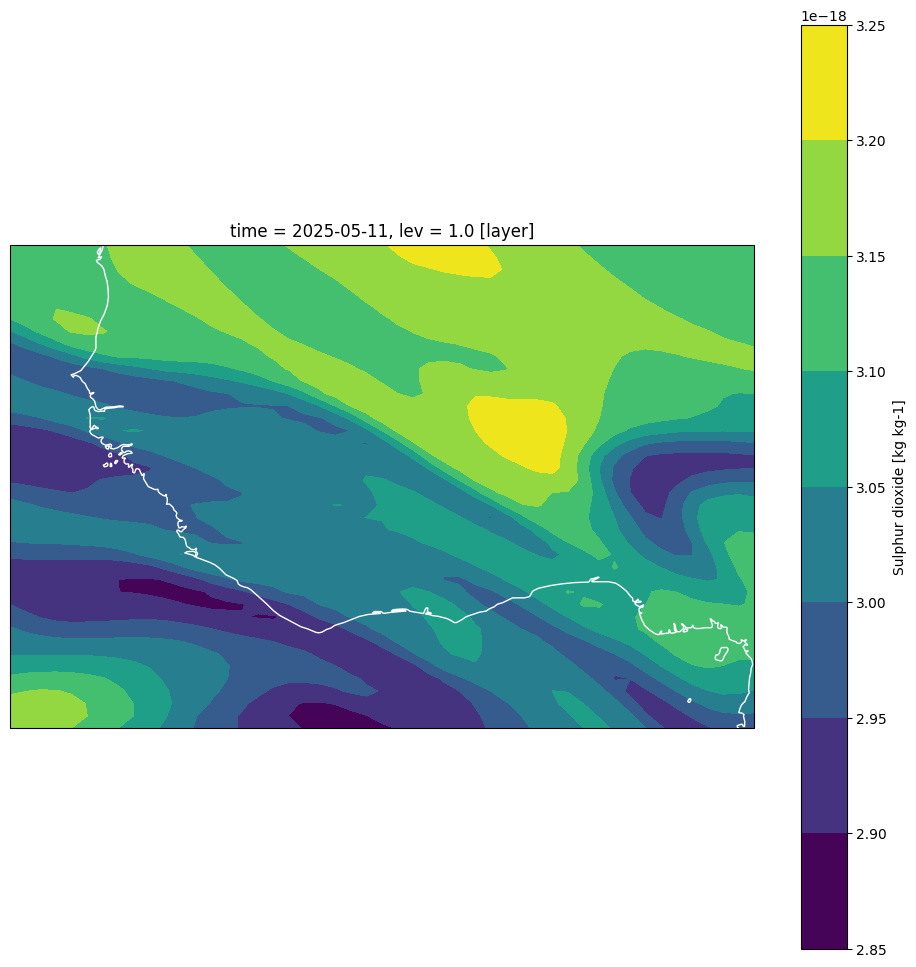

In [62]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
merra2_aero_sample['SO2'][0][0]SO2.plot.contourf(ax=ax1)
ax1.coastlines(color='w')


In [81]:
era5_ew4_dir = ew4_dir / 'ERA5' / 'hourly' / 'pl_levels'

In [82]:
era5_fname_template = 'ERA5_{dt.year:04d}_{dt.month:02d}_{dt.day:02d}_WAf_pl.nc'

In [86]:
era5_sample = xarray.open_dataset(era5_ew4_dir / era5_fname_template.format(dt=datetime.datetime(2016,7,23,9,0)))

In [87]:
era5_sample

<xarray.Dataset> Size: 99MB
Dimensions:    (time: 24, level: 3, latitude: 101, longitude: 189)
Coordinates:
  * time       (time) datetime64[ns] 192B 2016-07-23 ... 2016-07-23T23:00:00
  * level      (level) int32 12B 925 850 650
  * latitude   (latitude) float32 404B 27.0 26.75 26.5 26.25 ... 2.5 2.25 2.0
  * longitude  (longitude) float32 756B -20.0 -19.75 -19.5 ... 26.5 26.75 27.0
Data variables:
    d          (time, level, latitude, longitude) float64 11MB ...
    z          (time, level, latitude, longitude) float64 11MB ...
    pv         (time, level, latitude, longitude) float64 11MB ...
    r          (time, level, latitude, longitude) float64 11MB ...
    q          (time, level, latitude, longitude) float64 11MB ...
    t          (time, level, latitude, longitude) float64 11MB ...
    u          (time, level, latitude, longitude) float64 11MB ...
    v          (time, level, latitude, longitude) float64 11MB ...
    w          (time, level, latitude, longitude) float64 11MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2022-04-28 11:16:35 GMT by grib_to_netcdf-2.24.3: /opt/ecmw...